## Exploratory data analysis (EDA)

This is the very first data analysis I do on my own. 
Please take the informations on this notebook with a grain of salt. 
I'm open to all improvements (even rewording), don't hesitate to leave me a comment or upvote if you found it useful. 
If I'm completely wrong somewhere or if my findings makes no sense don't hesitate to leave me a comment.

Influenced by: neue fische Bootcamp - AI Engineering

The purpose of this EDA is to find insights and support a client with buy or sell houses.

We will proceed as follow:

<img src="http://sharpsightlabs.com/wp-content/uploads/2016/05/1_data-analysis-for-ML_how-we-use-dataAnalysis_2016-05-16.png" />

[Source](http://sharpsightlabs.com/blog/data-analysis-machine-learning-example-1/)

Where each steps (Data exploration, Data cleaning, Model building, Presenting results) will belongs to 1 notebook.
I will write down a lot of details in this notebook (even some which may seems obvious by nature), as a beginner it's important for me to do so.    

## DATA EXPLORATION (Preparations)

### For the preparations lets first import the necessary libraries and load the files needed for our EDA

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno
import geopandas as gpd
from shapely.geometry import Point
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

### read data

In [3]:
df = pd.read_csv('projectdata/joined_king_county.csv')

### Some Data Exploratory

In [ ]:
print("Header of 5 rows:")
display(df.head())

print("Information about datatypes")
display(df.info())

print("Describe about min/max, quartile, count...")
display(df.describe())

print("every column to sort or optimize it later")
display(df.columns)

In [ ]:
print(msno.matrix(df))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

##--- Box plot ---
sns.boxplot(
    data=df, x="condition", y="price", hue="waterfront", palette="pastel", ax=axes[0]
)
axes[0].set_title("Box Plot", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Price ($)")

sns.violinplot(
    data=df,
    x="condition",
    y="price",
    hue="waterfront",
    split=True,
    palette="pastel",
    ax=axes[1],
)
axes[1].set_title("Violin Plot (split by waterfront)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Price ($)")

plt.suptitle(
    "Price by Condition & Waterfront: Two Ways to See the Same Data",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## DATA CLEANING (Output: Data_Quality_Score)

In [5]:
## Drop implausible columns
df_opti = df.drop(columns=["id.1"])
display(df_opti.head())

## Defining missing and implausible values
cols_with_na = df.columns[df.isna().any()].tolist()
cols_no_zero = ["price","bedrooms","bathrooms","sqft_living","sqft_lot","floors",
                "condition","grade","sqft_above","zipcode","lat","long",
                "sqft_living15","sqft_lot15","yr_built"]

## searching for duplicate house_id
duplicates = df["house_id"].duplicated(keep="first").sum()
print(f"Duplicates in data:\n{duplicates}\n")

## serching for real duplicates
real_duplicates = df[df.duplicated(subset=["house_id", "date"], keep="first")]
print(f"Real duplicates in dataframe:\n{len(real_duplicates)}\n")

## Show corrupt datas in:
print(f"Missing Values(NaN) in column:\n{cols_with_na}")


,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0


Duplicates in data:
177

Real duplicates in dataframe:
0

Missing Values(NaN) in column:
['waterfront', 'view', 'sqft_basement', 'yr_renovated']


In [6]:
## Fixing values and datatypes
# Filling NaN from duplicate (must happen BEFORE scaling/casting)
df_opti[cols_with_na] = df_opti.groupby("house_id")[cols_with_na].transform(lambda x: x.ffill().bfill())

# yr_renovated remove false data (divided by 10)
mask = df_opti["yr_renovated"] > 0
df_opti.loc[mask, "yr_renovated"] = df_opti.loc[mask, "yr_renovated"] / 10

# dtypes optimization
df_opti["date"] = pd.to_datetime(df_opti["date"])
df_opti["yr_renovated"] = df_opti["yr_renovated"].astype("Int64") 

In [7]:
## Data Quality Checks
missing = df_opti[cols_with_na].isna().sum()
print(f"Missing Values in columns:\n{missing.to_string()}\n")

null_val = (df_opti[cols_no_zero] == 0).sum()
print(f"Zero values in columns:\n{null_val.to_string()}\n")

df_corrupt = df_opti[df_opti[cols_with_na].isna().any(axis=1)]
display(df_corrupt[["house_id"] + cols_with_na])

df_dqs = (df_opti[cols_with_na].isna().sum() / len(df_opti) * 100).round(2)
print(f"Percentage of data quality lose:\n{df_dqs.to_string()}\n")

zero_pct = (df_opti[cols_no_zero] == 0).sum() / len(df_opti) * 100
print(f"Zero values in % per column:\n"
      f"{zero_pct[zero_pct>0].round(2).to_string()}\n"
      f"nothing else")

Missing Values in columns:
waterfront       2391
view               63
sqft_basement     452
yr_renovated     3848

Zero values in columns:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
condition        0
grade            0
sqft_above       0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
yr_built         0



,house_id,waterfront,view,sqft_basement,yr_renovated
0,7129300520,NaN,0.0,0.0,0
2,5631500400,0.0,0.0,0.0,<NA>
6,1321400060,0.0,0.0,NaN,0
7,2008000270,0.0,NaN,0.0,0
10,1736800520,NaN,0.0,1700.0,0
...,...,...,...,...,...
21583,7202300110,0.0,0.0,0.0,<NA>
21586,844000965,NaN,0.0,0.0,0
21587,7852140040,NaN,0.0,0.0,0
21589,3448900210,0.0,NaN,0.0,0


Percentage of data quality lose:
waterfront       11.07
view              0.29
sqft_basement     2.09
yr_renovated     17.82

Zero values in % per column:
Series([], )
nothing else


In [8]:
## filling every unrelevant nan with 0
df_opti[["view","sqft_basement","yr_renovated"]] = df_opti[["view","sqft_basement","yr_renovated"]].fillna(0)
dqs_pct = (df_opti[cols_with_na].isna().sum() / len(df_opti) * 100).round(2)
print(f"Percentage of data quality lose:\n{dqs_pct.to_string()}\n")
df_clean = df_opti.copy()
df_clean.head()


Percentage of data quality lose:
waterfront       11.07
view              0.00
sqft_basement     0.00
yr_renovated      0.00



,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.0,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,NaN,...,7,1180.0,0.0,1955,0,98178,47.5112,-122.257,1340.0,5650.0
1,2014-12-09,538000.0,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,7,2170.0,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0
2,2015-02-25,180000.0,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,6,770.0,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0
3,2014-12-09,604000.0,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,7,1050.0,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0
4,2015-02-18,510000.0,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,8,1680.0,0.0,1987,0,98074,47.6168,-122.045,1800.0,7503.0


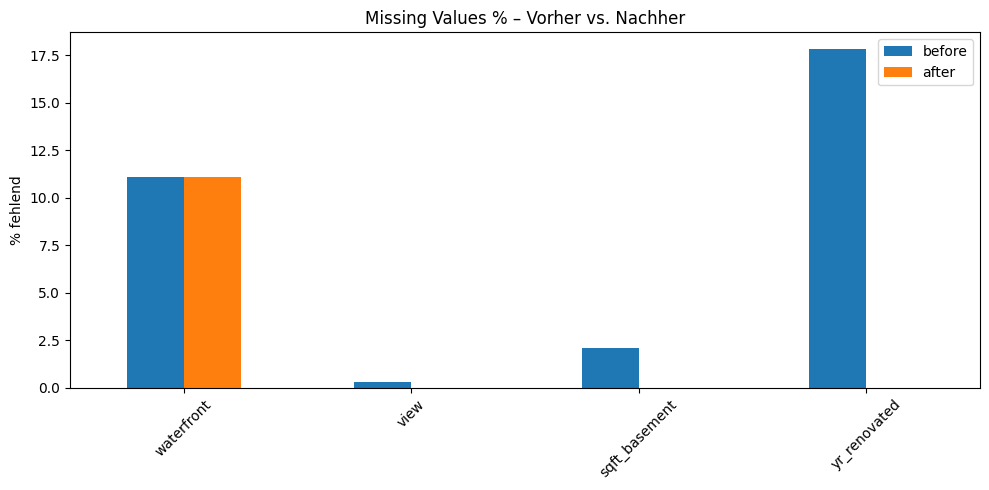

In [9]:
before = (df[cols_with_na].isna().sum() / len(df) * 100).round(2)
after = (df_clean[cols_with_na].isna().sum() / len(df_clean) * 100).round(2)


compare = pd.DataFrame({"before": before, "after": after})
compare.plot(kind="bar", rot=45, figsize=(10,5), title="Missing Values % – Before vs. After")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()

## Client Presentation

| Jennifer Montgomery | Buyer  | High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year 

Hypothesis directly after first Data review
1. Houses sold with waterfront are 30% higher priced	
2. Houses with a waterfront are mostly 20 years older than the other ones	
3. Location of houses with waterfront, renovated and high grades are immensely expensive and are mostly (80%) located near cities or big lakes

## MODEL BUILDING

### Optimizing the data by real geometry-data of water body from king county
https://gis-kingcounty.opendata.arcgis.com/datasets/156e6835b3594b62a9de201ae1c37b0e_0/explore?location=47.659234%2C-123.032192%2C7


In [10]:
## Load water body details polygons from geoJSON file 
gdf_water = gpd.read_file("projectdata/WTRBDY_DET_AREA_.geojson")

## Convert to EPSG:4326 standard GPS coordinate system (lat/long same as houses data)
gdf_water = gdf_water.to_crs("EPSG:4326")

## Convert house lat/long into point geometry data (same CRS as water)
gdf_houses = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["long"], df_clean["lat"]),
    crs="EPSG:4326"
)
#preview
display(gdf_houses.head())
display(gdf_water.head())

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,geometry
0,2014-10-13,221900.0,7129300520,1,3.0,1.00,1180.0,5650.0,1.0,NaN,...,1180.0,0.0,1955,0,98178,47.5112,-122.257,1340.0,5650.0,POINT (-122.257 47.5112)
1,2014-12-09,538000.0,6414100192,2,3.0,2.25,2570.0,7242.0,2.0,0.0,...,2170.0,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,POINT (-122.319 47.721)
2,2015-02-25,180000.0,5631500400,3,2.0,1.00,770.0,10000.0,1.0,0.0,...,770.0,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,POINT (-122.233 47.7379)
3,2014-12-09,604000.0,2487200875,4,4.0,3.00,1960.0,5000.0,1.0,0.0,...,1050.0,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,POINT (-122.393 47.5208)
4,2015-02-18,510000.0,1954400510,5,3.0,2.00,1680.0,8080.0,1.0,0.0,...,1680.0,0.0,1987,0,98074,47.6168,-122.045,1800.0,7503.0,POINT (-122.045 47.6168)


,OBJECTID,FEATURE_ID,NAME,WTRBDY_ID,CREATE_USER,CREATED_DATE,EDIT_USER,EDITED_DATE,SUBSET_CD,SUBSET,TYPE_CD,FEAT_TYPE,WATER_CD,WATER,RATE_CD,RATE,SOURCE_CD,DATASOURCE,geometry
0,1,1,,2002,highv,"Thu, 25 Feb 2016 13:51:10 GMT",highv,"Fri, 08 Jul 2016 08:15:45 GMT",0,Wtrbdy all,421,Lake or pond,1,Water,1,Current,3230,2015 Aerial Mapping Project,"POLYGON ((-122.22285 47.39247, -122.22283 47.3..."
1,2,2,,2002,highv,"Thu, 25 Feb 2016 13:51:10 GMT",highv,"Mon, 23 May 2016 07:59:11 GMT",0,Wtrbdy all,421,Lake or pond,1,Water,1,Current,3230,2015 Aerial Mapping Project,"POLYGON ((-122.26768 47.39142, -122.26767 47.3..."
2,3,170,,2002,highv,"Thu, 25 Feb 2016 13:51:10 GMT",NaN,NaN,0,Wtrbdy all,421,Lake or pond,1,Water,1,Current,3210,2012 Aerial Mapping Project,"POLYGON ((-122.2197 47.10259, -122.21978 47.10..."
3,4,175,,2002,highv,"Thu, 25 Feb 2016 13:51:10 GMT",highv,"Tue, 16 Aug 2016 12:39:33 GMT",0,Wtrbdy all,421,Lake or pond,1,Water,1,Current,3230,2015 Aerial Mapping Project,"POLYGON ((-121.97424 47.267, -121.97423 47.266..."
4,5,177,,2002,highv,"Thu, 25 Feb 2016 13:51:10 GMT",highv,"Wed, 29 Jun 2016 13:51:20 GMT",0,Wtrbdy all,421,Lake or pond,1,Water,1,Current,3230,2015 Aerial Mapping Project,"POLYGON ((-122.07921 47.26501, -122.07917 47.2..."


In [11]:
## convert both to a metric CRS (meters instead degrees) -> real calculation
gdf_houses_m = gdf_houses.to_crs("EPSG:32610")
gdf_water_m = gdf_water.to_crs("EPSG:32610")

# find nearest water body per house + distance in meter
gdf_joined = gpd.sjoin_nearest(gdf_houses_m, gdf_water_m, distance_col="dist_to_water")

# find duplicate matches (if a house has multiple equally-near water bodies)
gdf_joined = gdf_joined[~gdf_joined.index.duplicated(keep="first")]


In [ ]:
# ## export only house_id + dist_to_water (no need to re-run the spatial join every time)
# gdf_joined[["house_id", "dist_to_water"]].to_csv("dist_to_water.csv", index=False)

# dist_df = pd.read_csv("dist_to_water.csv")
# df_clean = df_clean.merge(dist_df, on="house_id", how="left")

# gdf_joined.to_file("gdf_joined.gpkg", driver="GPKG")

In [17]:
# write distance back to new dataframe
df_super = df_clean.copy()

df_super["dist_to_water"] = gdf_joined["dist_to_water"]

## Keep only the most recent sale per house_id (drop older duplicate sales)
df_super = df_super.sort_values("date").drop_duplicates(subset="house_id", keep="last")

<Axes: xlabel='dist_to_water'>

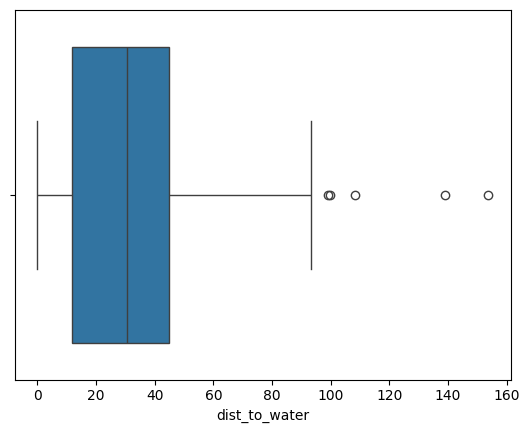

In [18]:
df_super[df_super["waterfront"] == 1]["dist_to_water"].describe()
sns.boxplot(x=df_super[df_super["waterfront"] == 1]["dist_to_water"])

In [19]:
## Define empirical threshold based on confirmed waterfront houses (median distance)
# water_threshold_m = df_super[df_super["waterfront"] == 1]["dist_to_water"].median()  # coded with variable
water_threshold_m = 25  # hardcoded

## flag hidden waterfront before overwriting waterfront column
df_super["is_hidden_waterfront"] = (df_super["waterfront"] == 0) & (df_super["dist_to_water"] < water_threshold_m)

## now apply threshold to overwrite waterfront (confirmed + hidden = 1)
df_super.loc[df_super["is_hidden_waterfront"], "waterfront"] = 1

display(df_super["waterfront"].value_counts())
display(df_super["is_hidden_waterfront"].sum())

waterfront
0.0    18789
1.0      271
Name: count, dtype: int64

np.int64(125)

## Hypothesis 1 -
### "Houses sold with waterfront are 30% higher priced"

In [38]:
df_super["price_per_sqft"] = df_super["price"] / df_super["sqft_living"]
df_super.groupby("waterfront")["price_per_sqft"].mean()

waterfront
0.0    263.179409
1.0    388.466341
Name: price_per_sqft, dtype: float64

In [39]:
## Hypothesis 1: Houses with waterfront are 30% higher priced
price_wf = df_super[df_super["waterfront"] == 1]["price"].mean()
price_no_wf = df_super[df_super["waterfront"] == 0]["price"].mean()

pct_diff = ((price_wf - price_no_wf) / price_no_wf * 100).round(2)
print(f"Waterfront mean price: {price_wf:.0f}")
print(f"No-waterfront mean price: {price_no_wf:.0f}")
print(f"Difference: {pct_diff}%")

Waterfront mean price: 1192816
No-waterfront mean price: 533812
Difference: 123.45%


In [40]:
price_wf = df_super[df_super["waterfront"] == 1]["price"].mean()
price_no_wf = df_super[df_super["waterfront"] == 0]["price"].mean()
pct_diff = ((price_wf - price_no_wf) / price_no_wf * 100).round(1)

summary = df_super.groupby(["grade", "waterfront"])["price"].mean().reset_index()
summary["waterfront"] = summary["waterfront"].map({0: "No Waterfront", 1: "Waterfront"})

pivot = summary.pivot(index="grade", columns="waterfront", values="price")
pivot["pct_diff"] = ((pivot["Waterfront"] - pivot["No Waterfront"]) / pivot["No Waterfront"] * 100).round(1)

fig = px.bar(
    summary, x="grade", y="price", color="waterfront", barmode="group",
    title="Average Price by Grade: Waterfront vs. No Waterfront",
    color_discrete_sequence=["#a3c4dc", "#0e6ba8"]
)

## Add % difference as annotation above each grade group
for grade in pivot.index:
    if pd.notna(pivot.loc[grade, "pct_diff"]):
        fig.add_annotation(
            x=grade,
            y=pivot.loc[grade, "Waterfront"],
            text=f"{pivot.loc[grade, 'pct_diff']:+.1f}%",
            showarrow=False,
            yshift=15,
            font=dict(size=11, color="#0e6ba8")
        )

fig.update_layout(template="plotly_white", yaxis_title="Average Price ($)", xaxis_title="Grade")
fig.show()


In [41]:
df_super["price_per_sqft"] = df_super["price"] / df_super["sqft_living"]

df_super["water_status"] = "no_waterfront"
df_super.loc[df_super["waterfront"] == 1, "water_status"] = "waterfront"
df_super.loc[df_super["is_hidden_waterfront"], "water_status"] = "hidden_waterfront"

fig = px.box(df_super, x="water_status", y="price_per_sqft", color="water_status",
             title="Price per sqft by Waterfront Status", template="plotly_white")
fig.show()

## Hypothesis 2 - 
### "Houses with a waterfront are mostly 20 years older than the other ones"

In [45]:
## Hypothesis 2: Waterfront houses are ~20 years older
current_year = 2015  # dataset's sales period
df_super["water_status"] = "no_waterfront"
df_super.loc[df_super["waterfront"] == 1, "water_status"] = "waterfront"
df_super.loc[df_super["is_hidden_waterfront"], "water_status"] = "hidden_waterfront"

df_super["house_age"] = current_year - df_super["yr_built"]
df_super["is_renovated"] = df_super["yr_renovated"] > 0

summary = df_super.groupby("water_status").agg(
    avg_age=("house_age", "mean"),
    renovated_pct=("is_renovated", "mean")
).round(1)
summary["renovated_pct"] = summary["renovated_pct"] * 100
summary

combined_age = df_super[df_super["water_status"].isin(["waterfront","hidden_waterfront"])]["house_age"].mean()
no_wf_age = df_super[df_super["water_status"] == "no_waterfront"]["house_age"].mean()

print(f"Combined (waterfront+hidden) avg age: {combined_age:.1f} years")
print(f"No waterfront avg age: {no_wf_age:.1f} years")
print(f"Difference: {(combined_age - no_wf_age):.1f} years")

Combined (waterfront+hidden) avg age: 44.5 years
No waterfront avg age: 43.9 years
Difference: 0.6 years


In [46]:
avg_age = df_super.groupby("water_status")["house_age"].mean()

fig = px.bar(
    avg_age.reset_index(),
    x="water_status", y="house_age", color="water_status",
    title="Average House Age by Waterfront Status",
    color_discrete_sequence=["#a3c4dc", "#0e6ba8", "#f2a65a"],
    text_auto=".1f"
)

## Add % difference vs. no_waterfront as annotation
base = avg_age["no_waterfront"]
for status in avg_age.index:
    if status != "no_waterfront":
        pct = ((avg_age[status] - base) / base * 100).round(1)
        fig.add_annotation(
            x=status, y=avg_age[status],
            text=f"{pct:+.1f}%",
            showarrow=False, yshift=20,
            font=dict(size=12, color="black")
        )

fig.update_layout(template="plotly_white", yaxis_title="Average Age (years)", xaxis_title="", showlegend=False)
fig.show()

## Hypothesis 3 -
### "Location of houses with waterfront, renovated and high grades are immensely expensive and are mostly (80%) located near cities or big lakes"

In [47]:
## Calculate area in square meters (using metric CRS)
gdf_water_m["area_sqm"] = gdf_water_m.geometry.area

## Check biggest named lakes
gdf_water_m[gdf_water_m["NAME"] != ""].sort_values("area_sqm", ascending=False)[["NAME","FEAT_TYPE","area_sqm"]].head(10)

,NAME,FEAT_TYPE,area_sqm
17711,Puget Sound,"Bays, estuaries, gulfs, oceans",2.359865e+10
16283,Lake Washington,Lake or pond,8.911610e+07
15720,Lake Sammamish,Lake or pond,1.969749e+07
10008,Lake Tapps,Lake or pond,1.354466e+07
7653,Alder Reservoir,Reservoir,1.180864e+07
13539,Keechelus Lake,Lake or pond,9.113985e+06
13413,Chester Morse Lake,Reservoir,7.908370e+06
1235,Spada Lake,Lake or pond,7.183111e+06
16597,Snohomish River,River or stream,5.980099e+06
12068,Stillaguamish River,River or stream,5.949165e+06


In [67]:
## Build the Hypothesis 3 subset: waterfront + renovated + high grade
df_hyp3 = df_super[
    (df_super["waterfront"] == 1) & (df_super["is_renovated"]) & (df_super["grade"] >= 9)
].copy()
df_hyp3["label"] = df_hyp3["house_id"].astype(str)

min_size = 10
max_size = 25
df_hyp3["marker_size"] = min_size + (df_hyp3["price"] - df_hyp3["price"].min()) / (df_hyp3["price"].max() - df_hyp3["price"].min()) * (max_size - min_size)

cities = pd.DataFrame({
    "name": ["Seattle", "Bellevue", "Kirkland", "Renton"],
    "lat": [47.6062, 47.6101, 47.6769, 47.4829],
    "lon": [-122.3321, -122.2015, -122.2059, -122.2171]
})

fig = go.Figure()

## Black outline layer (behind houses)
fig.add_trace(go.Scattermap(
    lat=df_hyp3["lat"], lon=df_hyp3["long"],
    mode="markers",
    marker=dict(size=df_hyp3["marker_size"]+6, color="black"),
    hoverinfo="skip",
    showlegend=False
))

## Colored house markers with labels
fig.add_trace(go.Scattermap(
    lat=df_hyp3["lat"], lon=df_hyp3["long"],
    mode="markers+text",
    marker=dict(size=df_hyp3["marker_size"], color=df_hyp3["price"], colorscale="YlOrRd", showscale=True),
    text=df_hyp3["label"],
    textfont=dict(color="black", size=11),
    hovertext=df_hyp3["house_id"].astype(str) + " | $" + df_hyp3["price"].astype(str),
    hoverinfo="text",
    showlegend=False
))

## City markers
fig.add_trace(go.Scattermap(
    lat=cities["lat"], lon=cities["lon"],
    mode="markers+text",
    marker=dict(size=10, color="blue"),
    text=cities["name"],
    textposition="top right",
    hoverinfo="text",
    showlegend=False
))

fig.update_layout(
    map=dict(style="open-street-map", zoom=9.5, center=dict(lat=df_hyp3["lat"].mean(), lon=df_hyp3["long"].mean())),
    title="Expensive Waterfront Houses (Renovated, High Grade)",
    margin=dict(l=0,r=0,t=40,b=0)
)
fig.show()

## SHOW OFF: candidates marking

In [ ]:
df_candidates = df_super[df_super["waterfront"] == 1]
display(df_candidates.head())

display(df_super["grade"].describe())
sns.boxplot(x=df_super["grade"])

# grade >= 9, because this was computed from all waterfront houses in the 75th percentile

,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,dist_to_water,is_hidden_waterfront
12030,2014-05-06,513000.0,6641020160,12031,4.0,2.50,2000.0,5684.0,2.0,1.0,...,0.0,1996,0,98028,47.7443,-122.220,2210.0,7066.0,20.188691,True
19955,2014-05-08,988500.0,2623039019,19956,3.0,2.75,2015.0,16807.0,2.0,1.0,...,0.0,2007,0,98166,47.4500,-122.377,1780.0,12310.0,27.814332,False
4009,2014-05-09,2400000.0,724069059,4010,3.0,2.25,3000.0,11665.0,1.5,1.0,...,0.0,2001,0,98075,47.5884,-122.086,3000.0,15959.0,30.831454,False
13235,2014-05-09,311100.0,8558600085,13236,4.0,2.25,2130.0,8078.0,1.0,1.0,...,750.0,1977,0,98055,47.4482,-122.209,2300.0,8112.0,3.406244,True
1198,2014-05-09,254000.0,11900140,1199,3.0,2.50,1850.0,4597.0,2.0,1.0,...,0.0,2003,0,98042,47.3755,-122.136,2210.0,5000.0,21.134818,True


In [28]:
def calc_show_off(w_grade, w_lot, w_view, w_condition, w_renovated, max_price):
    ## normalize each variable 0-1, then combine with user-defined weights
    grade_n = (df_candidates["grade"] - df_candidates["grade"].min()) / (df_candidates["grade"].max() - df_candidates["grade"].min())
    lot_n = (df_candidates["sqft_lot"] - df_candidates["sqft_lot"].min()) / (df_candidates["sqft_lot"].max() - df_candidates["sqft_lot"].min())
    view_n = (df_candidates["view"] - df_candidates["view"].min()) / (df_candidates["view"].max() - df_candidates["view"].min())
    condition_n = (df_candidates["condition"] - df_candidates["condition"].min()) / (df_candidates["condition"].max() - df_candidates["condition"].min())
    renov_n = (df_candidates["yr_renovated"] > 0).astype(int)

    score = (w_grade*grade_n + w_lot*lot_n + w_view*view_n + w_condition*condition_n + w_renovated*renov_n) / (w_grade+w_lot+w_view+w_condition+w_renovated)

    result = df_candidates.copy()
    result["show_off_factor"] = score

    display(result[(result["grade"] >= 9) & (result["price"] <= max_price)]
             .sort_values("show_off_factor", ascending=False)
             .head(15)[["house_id","price","grade","show_off_factor","dist_to_water","is_hidden_waterfront"]])

widgets.interact(
    calc_show_off,
    w_grade=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.3),
    w_lot=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.3),
    w_view=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.2),
    w_condition=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.1),
    w_renovated=widgets.FloatSlider(min=0, max=1, step=0.1, value=0.1),
    max_price=widgets.IntSlider(min=int(df_candidates["price"].min()), max=int(df_candidates["price"].max()), step=50000, value=1000000)
)

interactive(children=(FloatSlider(value=0.3, description='w_grade', max=1.0), FloatSlider(value=0.3, descripti…

<function __main__.calc_show_off(w_grade, w_lot, w_view, w_condition, w_renovated, max_price)>

In [ ]:
df_super["water_status"] = "no_waterfront"
df_super.loc[df_super["waterfront"] == 1, "water_status"] = "waterfront"
df_super.loc[df_super["is_hidden_waterfront"], "water_status"] = "hidden_waterfront"

display(df_super.groupby("water_status")["price"].describe())

print(df.shape, df_clean.shape, df_super.shape)
display(df_super["waterfront"].value_counts())

# FORGOTTEN TASKS
## Data reconstructing by enhanced detective work on data and internet data?
Nottice btw....